
---

## 🔷 1. **Trace Plot**

### ✅ Purpose: Convergence & Mixing

* Shows sampled parameter values over iterations.
* Ideally looks like "fat fuzzy caterpillars" (stationary noise).

```python
def trace_plot(samples, label="x"):
    plt.plot(samples, lw=0.5)
    plt.title(f"Trace plot of {label}")
    plt.xlabel("Iteration")
    plt.ylabel(label)
    plt.show()
```

---

## 🔷 2. **Histogram / KDE Plot**

### ✅ Purpose: Marginal Posterior Distribution

* Shows empirical distribution of a parameter.

```python
def posterior_plot(samples, label="x"):
    sns.histplot(samples, kde=True, bins=30, stat='density')
    plt.title(f"Posterior of {label}")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.show()
```

---

## 🔷 3. **Autocorrelation Plot**

### ✅ Purpose: Diagnosing mixing efficiency

* Shows how much current samples depend on previous ones.

```python
from statsmodels.graphics.tsaplots import plot_acf

def acf_plot(samples, label="x"):
    plot_acf(samples, lags=50)
    plt.title(f"Autocorrelation of {label}")
    plt.show()
```

---

## 🔷 4. **2D Joint Density (KDE or Contour)**

### ✅ Purpose: Joint posterior structure / Correlation

* Useful for bivariate models or to inspect dependency.

```python
def joint_kde_plot(samples_2d):
    x, y = samples_2d[:, 0], samples_2d[:, 1]
    sns.kdeplot(x=x, y=y, fill=True, cmap="Blues")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Joint Posterior (KDE)")
    plt.axis("equal")
    plt.show()
```

---

## 🔷 5. **Pair Plot (Multivariate Posterior)**

### ✅ Purpose: View marginals and pairwise correlations

* Great for full posterior overview.

```python
def pair_plot(samples, labels):
    import pandas as pd
    df = pd.DataFrame(samples, columns=labels)
    sns.pairplot(df, kind='kde')
    plt.show()
```

---

## 🔷 6. **Rank Plot (R-hat diagnostics)**

### ✅ Purpose: Convergence diagnostic

* Shows how well chains mix. Flat rank histogram = good.

(*Use ArviZ for this*)

```python
import arviz as az
az.plot_rank(samples_array, var_names=["x"])
```

---

## 🔷 7. **Energy Diagnostic Plot (for HMC/NUTS)**

### ✅ Purpose: Detects divergences & tuning issues

* Ideal when using Hamiltonian/NUTS samplers.

```python
az.plot_energy(az.from_dict(posterior={"x": samples}))
```

---

## 🔷 8. **Effective Sample Size (ESS) Plot**

### ✅ Purpose: Shows efficiency of sampling

* Low ESS → poor mixing / high autocorrelation.

```python
az.plot_ess(az.from_dict(posterior={"x": samples}))
```

---

## 🔷 9. **Posterior Predictive Checks**

### ✅ Purpose: Model fit to observed data

* Compares observed data vs. simulated data from posterior.

```python
def posterior_predictive_check(y_obs, y_sim):
    sns.histplot(y_sim, label="Posterior Predictive", color="blue", kde=True)
    plt.axvline(np.mean(y_obs), color="red", label="Observed Mean")
    plt.legend()
    plt.title("Posterior Predictive Check")
    plt.show()
```

---

## 🔷 10. **Model Comparison Metrics Visualization**

### A. **WAIC / LOO bar plots**

```python
model_names = ["model1", "model2"]
waic_values = [-120.3, -123.7]
plt.bar(model_names, waic_values)
plt.ylabel("WAIC")
plt.title("Model Comparison (lower is better)")
plt.show()
```

---

## ✅ Summary Table: Graph Types vs Purpose

| Plot Type                  | Purpose                        | Tools       | Use With        |
| -------------------------- | ------------------------------ | ----------- | --------------- |
| Trace plot                 | Convergence, mixing            | matplotlib  | All             |
| Histogram / KDE            | Marginal posterior             | seaborn     | All             |
| Autocorrelation plot       | Mixing speed                   | statsmodels | All             |
| Joint 2D KDE / Contour     | Joint structure                | seaborn     | All             |
| Pair plot                  | Multivariate posterior         | seaborn     | All             |
| Rank plot                  | Convergence diagnostic (R-hat) | arviz       | MCMC            |
| Energy plot                | Detect divergences (HMC)       | arviz       | HMC             |
| ESS plot                   | Effective sample size          | arviz       | All             |
| Posterior predictive check | Model fit vs data              | seaborn     | All             |
| WAIC / LOO bar plot        | Model comparison               | matplotlib  | Bayesian models |

---



In [1]:
import matplotlib.pyplot as plt
import numpy as np

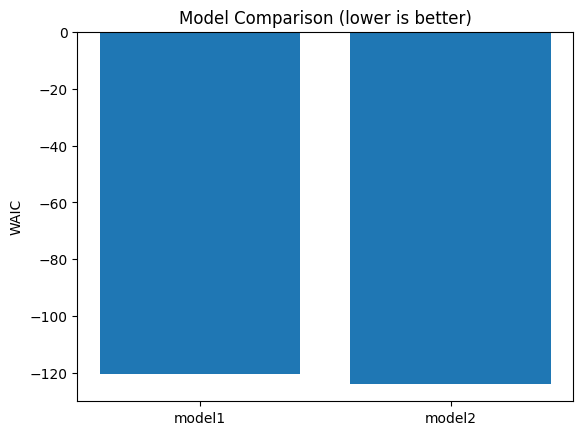

In [2]:
model_names = ["model1", "model2"]
waic_values = [-120.3, -123.7]
plt.bar(model_names, waic_values)
plt.ylabel("WAIC")
plt.title("Model Comparison (lower is better)")
plt.show()



---

## ✅ 1. **Predicted vs Actual (Scatter Plot)**

### 🔹 Purpose:

* Checks how close predictions are to the ground truth.
* Ideal fit = points lie along the 45° line.

### 🔹 Code:

```python
def scatter_actual_vs_predicted(y_true, y_pred):
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.axis("equal")
    plt.show()
```

---

## ✅ 2. **Residual Plot**

### 🔹 Purpose:

* Residual = $y_{\text{true}} - y_{\text{pred}}$
* Reveals bias (e.g., under/overestimation), heteroscedasticity.

### 🔹 Code:

```python
def residual_plot(y_true, y_pred):
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()
```

---

## ✅ 3. **Histogram of Residuals**

### 🔹 Purpose:

* Should be roughly symmetric and centered around zero.
* Indicates error distribution.

```python
def residual_histogram(y_true, y_pred):
    residuals = y_true - y_pred
    sns.histplot(residuals, kde=True, bins=30)
    plt.axvline(0, color='red', linestyle='--')
    plt.title("Histogram of Residuals")
    plt.xlabel("Residual")
    plt.show()
```

---

## ✅ 4. **Prediction Interval Plot (Uncertainty Bands)**

### 🔹 Purpose:

* Plots predicted mean + uncertainty (e.g., ±2 std or percentiles).
* Checks coverage of true data points.

```python
def prediction_interval_plot(X, y_true, y_mean, y_std):
    plt.plot(X, y_true, 'r.', label="Actual")
    plt.plot(X, y_mean, 'b-', label="Predicted mean")
    plt.fill_between(X, y_mean - 2*y_std, y_mean + 2*y_std, alpha=0.3, label="±2σ")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.title("Prediction with Uncertainty Bands")
    plt.legend()
    plt.show()
```

---

## ✅ 5. **Posterior Predictive Check (PPC) Histogram**

### 🔹 Purpose:

* Compares distribution of simulated data to observed data.
* Checks if model captures distributional structure.

```python
def posterior_predictive_check(y_obs, y_sim):
    sns.histplot(y_sim, label="Posterior Predictive", color="blue", kde=True, stat="density")
    sns.histplot(y_obs, label="Observed", color="red", kde=True, stat="density")
    plt.legend()
    plt.title("Posterior Predictive Check")
    plt.show()
```

---

## ✅ 6. **Calibration Plot (Reliability Diagram)**

### 🔹 Purpose:

* Used for probabilistic models.
* Compares predicted probabilities to observed frequencies.

```python
from sklearn.calibration import calibration_curve

def calibration_plot(y_prob, y_true):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
    plt.plot([0, 1], [0, 1], 'r--', label='Perfect')
    plt.xlabel("Predicted probability")
    plt.ylabel("Empirical probability")
    plt.title("Calibration Plot")
    plt.legend()
    plt.show()
```

---

## ✅ 7. **QQ Plot of Residuals**

### 🔹 Purpose:

* Quantile-Quantile plot checks normality of residuals.
* Should follow a straight line if residuals are Gaussian.

```python
import scipy.stats as stats

def qq_plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.show()
```

---

## ✅ 8. **Mean Absolute Error / RMSE Bar Plot (Per Model)**

### 🔹 Purpose:

* Quantifies prediction quality across models.

```python
def error_bar_plot(model_names, rmse_values):
    plt.bar(model_names, rmse_values)
    plt.ylabel("RMSE")
    plt.title("Model Comparison (Lower is Better)")
    plt.show()
```

---

## 📌 Summary: Graphs to Compare Predictions vs Actuals

| Graph Type                    | Purpose                                   | Best For                  |
| ----------------------------- | ----------------------------------------- | ------------------------- |
| Actual vs Predicted (Scatter) | Overall accuracy, alignment               | Regression                |
| Residual Plot                 | Bias, heteroscedasticity                  | All predictive models     |
| Residual Histogram            | Error distribution shape                  | Error diagnostics         |
| Prediction Interval Plot      | Uncertainty visualization                 | Bayesian or probabilistic |
| Posterior Predictive Check    | Match simulated vs observed distributions | Bayesian modeling         |
| Calibration Plot              | Probabilistic calibration                 | Probabilistic classifiers |
| QQ Plot                       | Normality of residuals                    | Model diagnostics         |
| Error Bar Plot                | Compare RMSE / MAE across models          | Model selection           |

---

